## Loading Initial Dataset

In [2]:
# install lz4 for Google Colab
!pip install lz4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 14.8 MB/s eta 0:00:00


In [3]:
from google.colab import files
import pandas as pd
import json
import lz4.frame
import copy
import os
from tqdm.notebook import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
import statistics

In [6]:
folder_path = '/content/drive/MyDrive/CMPE 256/Project/high_elo'
all_files = os.listdir(folder_path)

## First Clean

In [7]:
# The loop goes through and creates a data frame from the file data
# Also creates the new feature opponent switches
final_result = pd.DataFrame()
all_results = []
for f in tqdm(all_files, desc="Processing Files"):
  with lz4.frame.open(f'{folder_path}/{f}', "rb") as f:
    data = json.loads(f.read().decode("utf-8"))
  all_bench = []
  prev_rem = 6
  prev_poke = data['states'][0]['opponent_active_pokemon']['name']
  bench = {}
  prev_state = {}
  for i in range(len(data['states'])):
    name = data['states'][i]['opponent_active_pokemon']['name']
    rem = data['states'][i]['opponents_remaining']

    if prev_poke != name:
      bench.pop(name, None)
      bench[prev_poke] = prev_state
    if prev_rem != rem:
      bench.pop(prev_poke, None)
      pass


    prev_rem = rem
    prev_poke = name
    prev_state = copy.deepcopy(data['states'][i]['opponent_active_pokemon'])
    all_bench.append(copy.deepcopy(bench))


  bench_list = [list(x.values()) for x in all_bench]
  opponent_switches = pd.DataFrame({'opponent switches': bench_list})
  df = pd.DataFrame(data['states'])
  actions = pd.DataFrame({'action': data['actions']})
  result = pd.concat([df, opponent_switches, actions], axis=1)
  result = result[result['action'] > -1]
  all_results.append(result)

final_result = pd.concat(all_results, ignore_index=True)

Processing Files:   0%|          | 0/9334 [00:00<?, ?it/s]

In [8]:
final_result = final_result.rename(columns={'opponent switches': 'opponent_switches'})

In [9]:
final_result = final_result[final_result['action'] > -1]

In [10]:
final_result.columns

Index(['format', 'player_active_pokemon', 'opponent_active_pokemon',
       'available_switches', 'player_prev_move', 'opponent_prev_move',
       'opponents_remaining', 'player_conditions', 'opponent_conditions',
       'weather', 'battle_field', 'forced_switch', 'battle_won', 'battle_lost',
       'can_tera', 'opponent_teampreview', 'opponent_switches', 'action'],
      dtype='object')

## Data Distribution Check

In [11]:
# Adds up every instance of pokemon, moves, items, abilities, status, etc
pokemon_dict = defaultdict(int)
move_dict = defaultdict(int)
items_dict = defaultdict(int)
abilities_dict = defaultdict(int)
status_dict = defaultdict(int)
effect_dict = defaultdict(int)
weather_dict = defaultdict(int)
condition_dict = defaultdict(int)
battle_field_dict = defaultdict(int)

for row in tqdm(final_result.itertuples(), desc="Creating Counts"):

  weather_dict[row.weather] += 1
  condition_dict[row.player_conditions] += 1
  condition_dict[row.opponent_conditions] += 1
  battle_field_dict[row.battle_field] += 1

  for pokemon_obj in row.available_switches:
    pokemon_dict[pokemon_obj['name']] += 1
    status_dict[pokemon_obj['status']] += 1
    effect_dict[pokemon_obj['effect']] += 1

    for move in pokemon_obj['moves']:
      move_dict[move['name']] += 1

    items_dict[pokemon_obj['item']] += 1
    abilities_dict[pokemon_obj['ability']] += 1

  for pokemon_obj in row.opponent_switches:
    pokemon_dict[pokemon_obj['name']] += 1
    status_dict[pokemon_obj['status']] += 1
    effect_dict[pokemon_obj['effect']] += 1
    for move in pokemon_obj['moves']:
      move_dict[move['name']] += 1

    items_dict[pokemon_obj['item']] += 1
    abilities_dict[pokemon_obj['ability']] += 1



  pokemon = row.player_active_pokemon['name']
  pokemon_dict[pokemon] += 1

  for move in  row.player_active_pokemon['moves']:
      move_dict[move['name']] += 1


  status_dict[row.player_active_pokemon['status']] += 1
  effect_dict[row.player_active_pokemon['effect']] += 1
  items_dict[row.player_active_pokemon['item']] += 1
  abilities_dict[row.player_active_pokemon['ability']] += 1

  pokemon = row.opponent_active_pokemon['name']
  pokemon_dict[pokemon] += 1

  for move in  row.opponent_active_pokemon['moves']:
      move_dict[move['name']] += 1

  status_dict[row.opponent_active_pokemon['status']] += 1
  effect_dict[row.opponent_active_pokemon['effect']] += 1
  items_dict[row.opponent_active_pokemon['item']] += 1
  abilities_dict[row.opponent_active_pokemon['ability']] += 1


Creating Counts: 0it [00:00, ?it/s]

Num of Pokemons 171 | min 2 | max 217066 | mean 16092.30409356725 | median 623


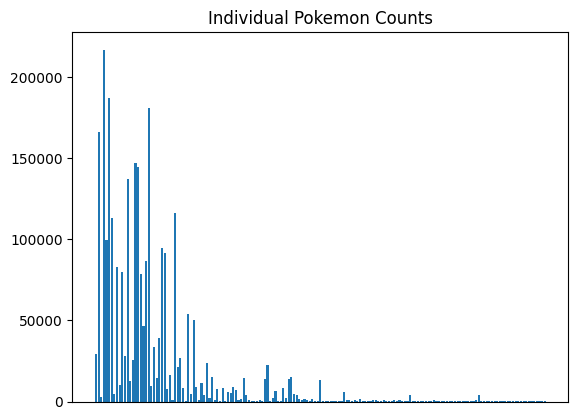

In [12]:
plt.bar(pokemon_dict.keys(), pokemon_dict.values(), )
plt.xticks([])
plt.title("Individual Pokemon Counts")
values = pokemon_dict.values()
print(f'Num of Pokemons {len(pokemon_dict)} | min {min(values)} | max {max(values)} | mean {statistics.mean(values)} | median {statistics.median(values)}')

Num of Moves 186 | min 4 | max 690298 | mean 45118.478494623654 | median 2099.5


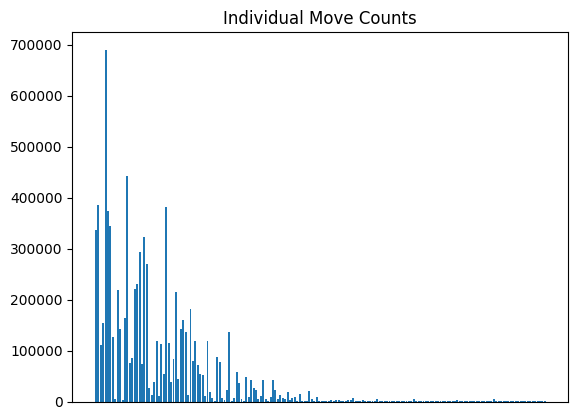

In [13]:
plt.bar(move_dict.keys(), move_dict.values(), )
plt.xticks([])
plt.title("Individual Move Counts")
values = move_dict.values()
print(f'Num of Moves {len(move_dict)} | min {min(values)} | max {max(values)} | mean {statistics.mean(values)} | median {statistics.median(values)}')

Num of Items 23 | min 3 | max 2172993 | mean 119642.78260869565 | median 231


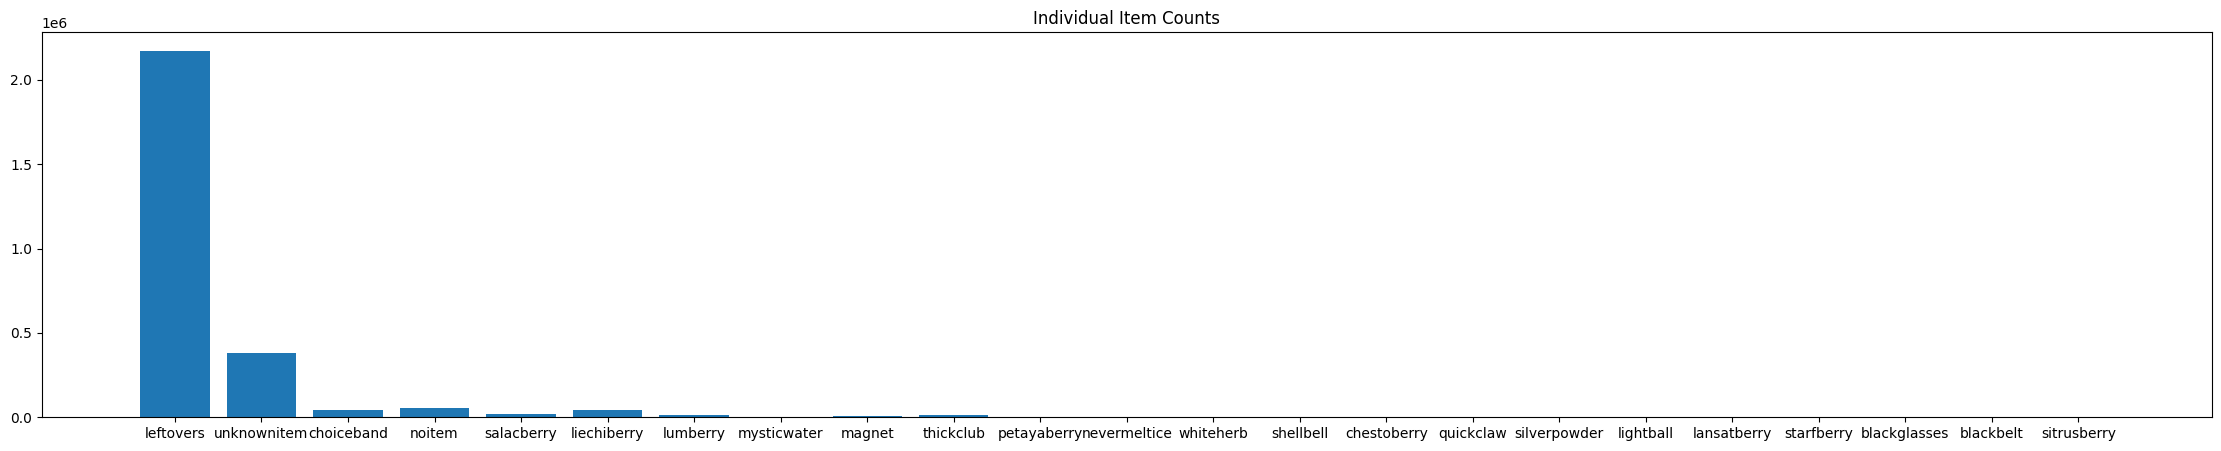

In [14]:
plt.figure(figsize=(28, 5))
plt.bar(items_dict.keys(), items_dict.values(), )
plt.title("Individual Item Counts")
values = items_dict.values()
print(f'Num of Items {len(items_dict)} | min {min(values)} | max {max(values)} | mean {statistics.mean(values)} | median {statistics.median(values)}')


Num of Abilities 68 | min 3 | max 355254 | mean 40467.41176470588 | median 5597.5


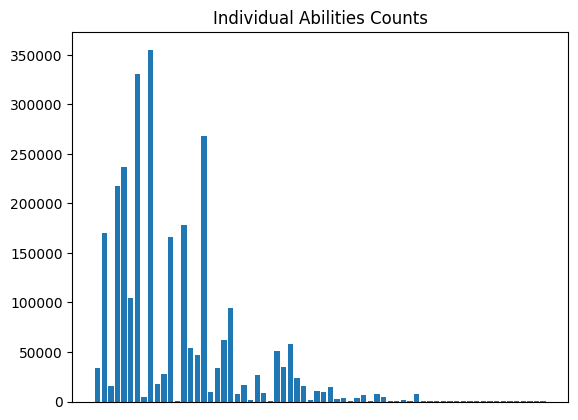

In [15]:
plt.bar(abilities_dict.keys(), abilities_dict.values(), )
plt.xticks([])
plt.title("Individual Abilities Counts")
values = abilities_dict.values()
print(f'Num of Abilities {len(abilities_dict)} | min {min(values)} | max {max(values)} | mean {statistics.mean(values)} | median {statistics.median(values)}')

Num of Status 8 | min 569 | max 2358389 | mean 343973 | median 70109.0


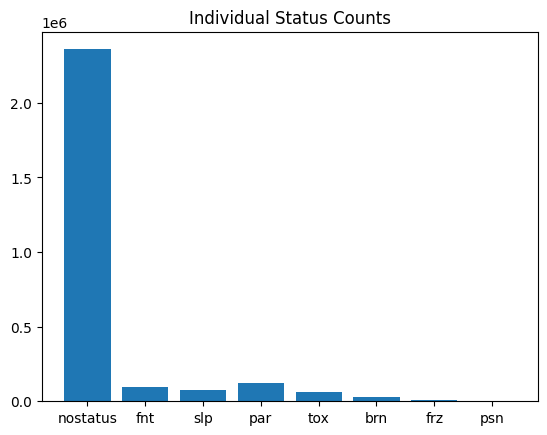

In [16]:
plt.bar(status_dict.keys(), status_dict.values(), )
plt.title("Individual Status Counts")
values = status_dict.values()
print(f'Num of Status {len(status_dict)} | min {min(values)} | max {max(values)} | mean {statistics.mean(values)} | median {statistics.median(values)}')

Num of Effects 29 | min 6 | max 2618426 | mean 94889.10344827586 | median 191


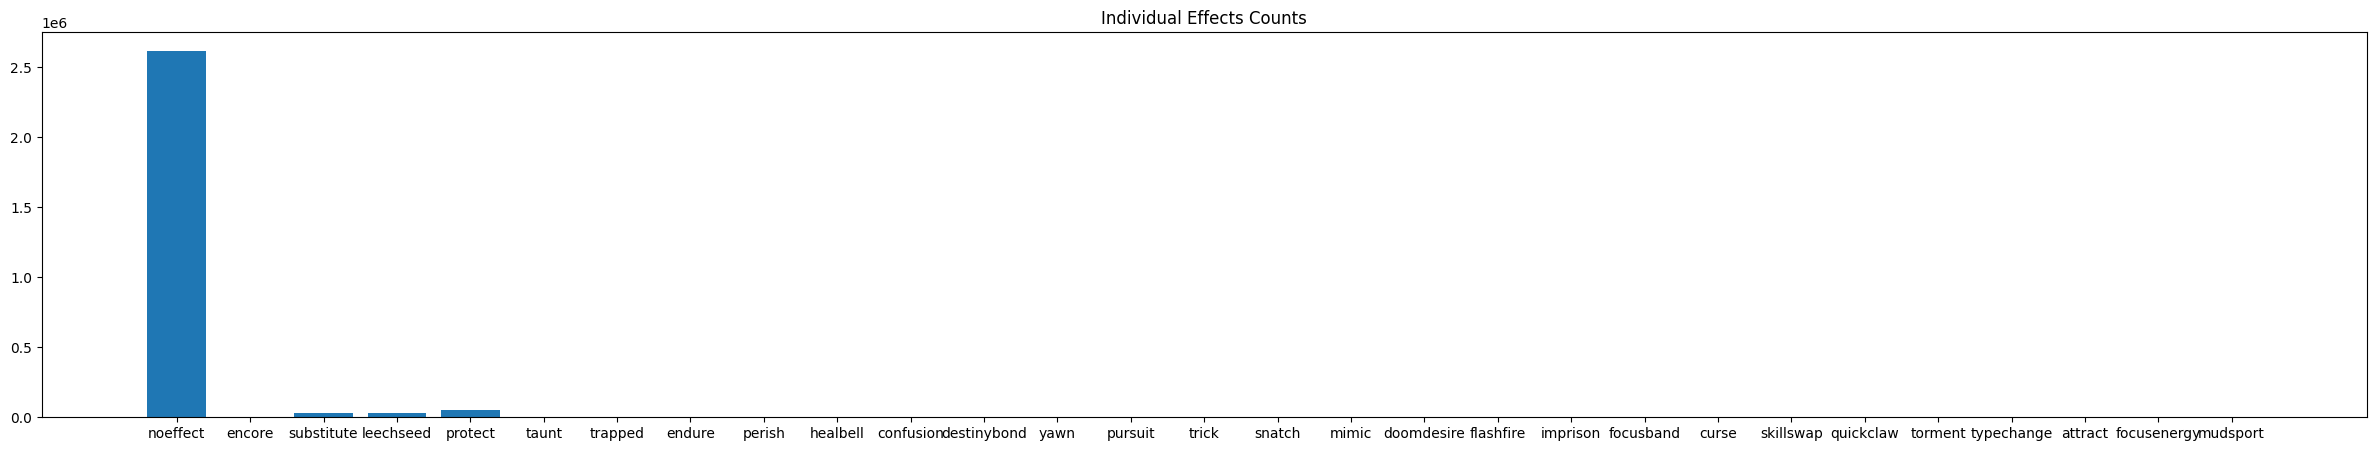

In [17]:
plt.figure(figsize=(30, 5))
plt.bar(effect_dict.keys(), effect_dict.values())
plt.title("Individual Effects Counts")
values = effect_dict.values()
print(f'Num of Effects {len(effect_dict)} | min {min(values)} | max {max(values)} | mean {statistics.mean(values)} | median {statistics.median(values)}')

Num of Weather 5 | min 11 | max 207408 | mean 69261.4 | median 4605


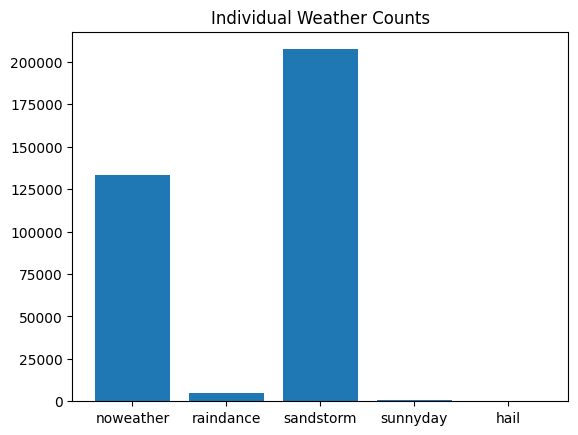

In [18]:
plt.bar(weather_dict.keys(), weather_dict.values())
plt.title("Individual Weather Counts")
values = weather_dict.values()
print(f'Num of Weather {len(weather_dict)} | min {min(values)} | max {max(values)} | mean {statistics.mean(values)} | median {statistics.median(values)}')

Num of Condition 5 | min 10 | max 467715 | mean 138522.8 | median 519


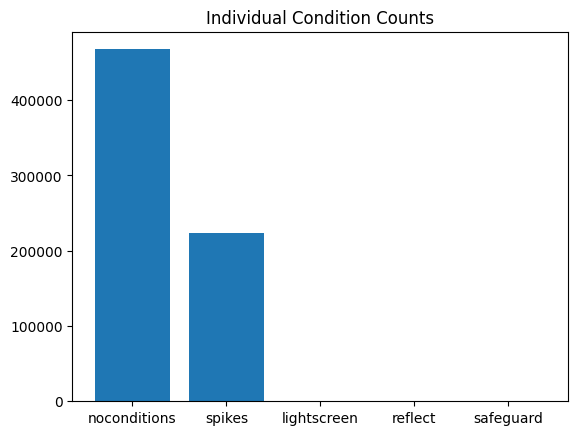

In [19]:
plt.bar(condition_dict.keys(), condition_dict.values())
plt.title("Individual Condition Counts")
values = condition_dict.values()
print(f'Num of Condition {len(condition_dict)} | min {min(values)} | max {max(values)} | mean {statistics.mean(values)} | median {statistics.median(values)}')

Num of Battle Field 1 | min 346307 | max 346307 | mean 346307 | median 346307


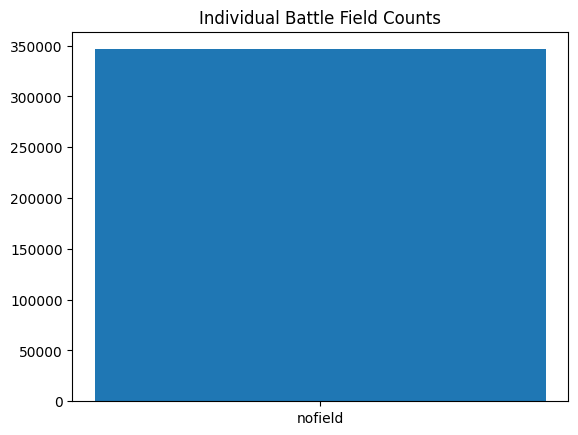

In [20]:
plt.bar(battle_field_dict.keys(), battle_field_dict.values())
plt.title("Individual Battle Field Counts")
values = battle_field_dict.values()
print(f'Num of Battle Field {len(battle_field_dict)} | min {min(values)} | max {max(values)} | mean {statistics.mean(values)} | median {statistics.median(values)}')

## Second Clean and Download

In [21]:
pokemon_df = final_result.drop(columns=['format', 'player_prev_move', 'opponent_prev_move', 'battle_won','battle_field', 'battle_lost', 'can_tera'])

In [22]:
# Additional cleaning to get dataset ready
# alphabetically sort pokemon and moves
# only take the "necessary" data
import torch

def process_pokemon_dict(data):

    boost_keys = sorted([k for k in data.keys() if k.endswith('_boost')])
    boosts_list = [data[k] for k in boost_keys]
    boosts_tensor = torch.tensor(boosts_list, dtype=torch.float32)

    filtered_moves = []
    for move in data['moves']:
        filtered_moves.append({
            'name': move['name'],
            'current_pp': move['current_pp']
        })
    filtered_moves.sort(key=lambda x: x['name'])

    return {
        'name': data.get('name'),
        'status': data.get('status'),
        'ability': data.get('ability'),
        'effect': data.get('effect'),
        'hp_pct': data.get('hp_pct'),
        'item': data.get('item'),
        'boosts': boosts_tensor,
        'moves': filtered_moves
    }

def process_pokemon_team_list(team_list):

    processed_team = [process_pokemon_dict(poke) for poke in team_list]
    processed_team.sort(key=lambda x: x['name'])

    return processed_team

In [25]:
pokemon_df['player_active_pokemon'] = pokemon_df['player_active_pokemon'].apply(process_pokemon_dict)
pokemon_df['opponent_active_pokemon'] = pokemon_df['opponent_active_pokemon'].apply(process_pokemon_dict)
pokemon_df['available_switches'] = pokemon_df['available_switches'].apply(process_pokemon_team_list)
pokemon_df['opponent_switches'] = pokemon_df['opponent_switches'].apply(process_pokemon_team_list)

In [27]:
pokemon_df.to_pickle('Gen3OUFinalParse.pkl')

In [28]:
files.download('Gen3OUFinalParse.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>